# Bridged Comparisons -- Time-to-Event Data

Here, we apply bridged comparison estimators for time-to-event data. Data for this example comes from the AIDS Clinical Trial Group (ACTG). The first study is the ACTG-320 trial which compared triple-therapy to dual-therapy for prevention of disease progression among persons with HIV. The second study the ACTG-175 trial which compared dual-therapy to mono-therapy for prevention of disease progression among persons with HIV. We are interested in estimating the effect of triple-therapy relative to mono-therapy in the ACTG-320 source population.

This example, along with variable definitions and harmonization, is provided in Zivich et al. (2025). Here, we use the pre-processed data to replicate those prior results. Note that the estimators being used here are slightly different, so results are not expected to match exactly.

## Setup

First, we load corresponding packages, functionalities, and the harmonized data.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cantilever.estimators.time_to_event import BridgeIPW, BridgeGComputation

In [19]:
d = pd.read_csv("data/actg_tte.csv")

Now we consider several different estimators

## G-computation

For the first estimator, we will consider the bridge g-computation estimator. First, we initialize the estimator in `BridgeGComputation` with the data and provide the column names corresponding to different aspects of the data. The following code applies this process.

In [20]:
bgcomp = BridgeGComputation(data=d, time='t', delta='delta', action='art', sample='study', censor='censor',
                            verbose=False)

G-computation is based on fitting a single nuisance model. Here, we only need to fit a model for the outcome. As this is time-to-event data, a model that can handle time-to-event data is needed. `BridgeGComputation` uses pooled logistic regression for this process. Specifically, 4 different pooled logistic regression models are fit, one for each study- and arm-specific combination.

In [21]:
bgcomp.outcome_model(model="male + black + idu + age + age_rs0 + age_rs1 + age_rs2 + C(karnof_cat)")

These models can then be used to estimate the risks under each of the various treatments with the ACTG-320 data. The following code applies this process

In [22]:
bgcomp.estimate_risks()

While we could examine the tabled results over time using `bgcomp.risks`, it is often helpful to instead examine a plot of the risks. The following code does this process for us.

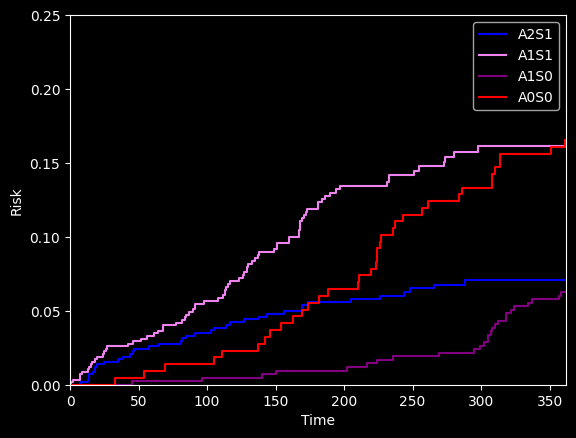

In [26]:
ax = bgcomp.plot_risks(colors=("blue", "violet", "purple", "red"))
ax.set_ylim([0, 0.25])
ax.legend()

From this plot, we can see there is substantial differences between the shared `A1` arms. We can formalize this comparison by explicitly calling the function to estimate the diagnostic basd on the shared arms. The following code applies this process and then generates a twister plot of those results

In [27]:
bgcomp.estimate_diagnostic()

Text(0.5, 1.0, 'Bridge G-computation Diagnostic')

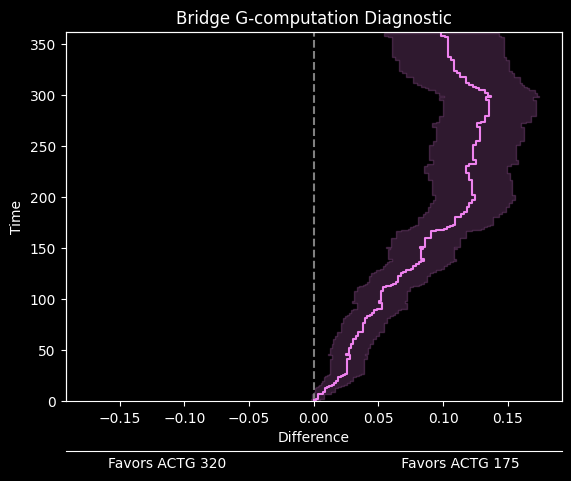

In [28]:
ax = bgcomp.plot_diagnostic(color='violet', favors_spacing="\t\t\t\t\t",
                            favors_label=("ACTG 320", "ACTG 175"))
ax.set_title("Bridge G-computation Diagnostic")

So we see substantial differences. Specifically, it looks like being in the ACTG 175 is protective. As discussed further in Zivich et al. (2025), this is due to different eligibility criteria between the two trials. Specifically, the trials had different inclusion criteria by CD4, an important immunological indicator for disease progression in HIV. As ACTG-175 recruited individuals at a last advanced stage, dual-therapy looks like it is more protective.

We can mitigate some of this bias by restricting the data by baseline CD4 as also done in Zivich et al. (2025). Here, we apply that restriction and then re-estimate the diagnostic

In [29]:
ds = d.loc[(d['cd4'] >= 50) & (d['cd4'] <= 300)].copy()

In [30]:
bgcomp = BridgeGComputation(data=ds, time='t', delta='delta', action='art', sample='study', censor='censor',
                            verbose=False)
bgcomp.outcome_model(model="male + black + idu + age + age_rs0 + age_rs1 + age_rs2 + C(karnof_cat)")
bgcomp.estimate_risks()  # Not necessary to call here, but speeds up diagnostic estimation
bgcomp.estimate_diagnostic()

(-0.2, 0.2)

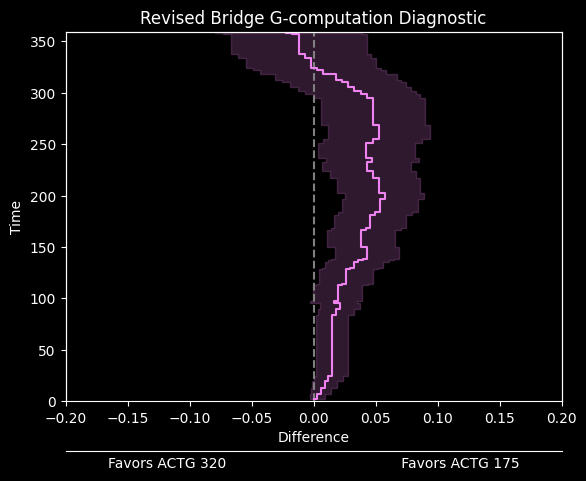

In [32]:
ax = bgcomp.plot_diagnostic(color='violet', favors_spacing="\t\t\t\t\t",
                            favors_label=("ACTG 320", "ACTG 175"))
ax.set_title("Revised Bridge G-computation Diagnostic")
ax.set_xlim([-0.2, 0.2])

While this is an improvement over the previous analysis, we still see some differences between the shared arms. We can also apply a statistical test for the full function based on the integrated risk difference. If the arms were equal, we would expect an integrated risk difference of zero.

This test is also applied with `estimate_diagnostic`, so we can simply look at those results.

In [33]:
bgcomp.diagnostic_test

,IRD,IRD_LCL,IRD_UCL,P-value
0,10.104273,1.057624,19.150923,0.02859


Here, the P-value is small (`0.03`) which is indicates there are substantial differences between the trials remaining. This diagnostic results would suggest that this fusion of trials was not successful. Here, we would not provide the results for the comparison of interest as a result.

To showcase the functionality of the software, we set aside this implication and estimate the difference comparing triple-therapy to mono-therapy. First, we will apply the multi-span estimator, which compares through the shared arms.

In [34]:
bgcomp.estimate_multi_span()

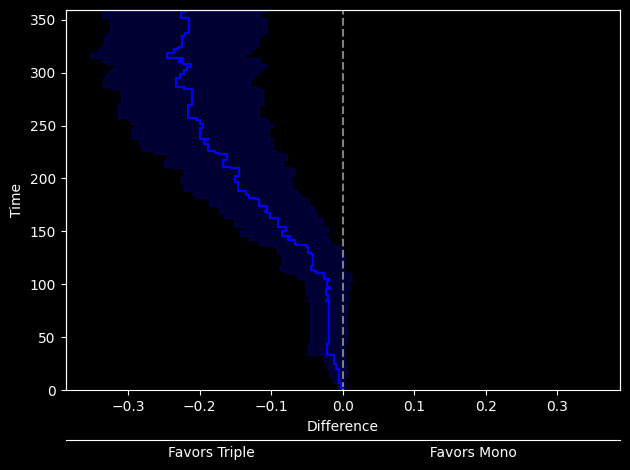

In [39]:
bgcomp.plot_multi_span(color='blue', favors_spacing='\t\t\t\t\t',
                       favors_label=("Triple", "Mono"))
plt.tight_layout()

An alternative is the single-span, which ignores the shared arms

C:\Users\pzivich\Documents\open-source\Delicatessen\delicatessen\estimation.py:123: RuntimeWarning: invalid value encountered in divide
  z_score = (self.theta - null) / se         # Compute the Z-score


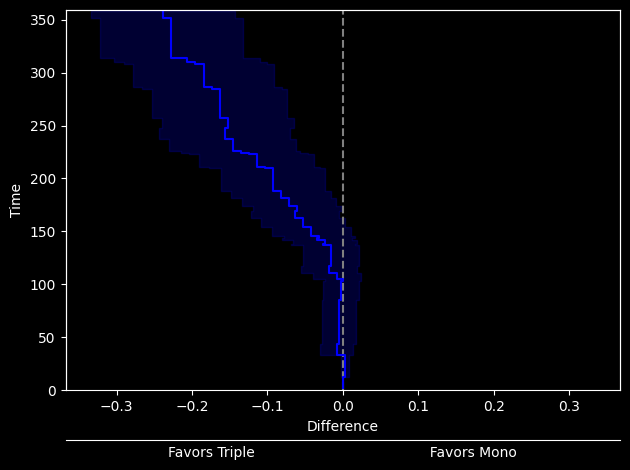

In [40]:
bgcomp.estimate_single_span()
bgcomp.plot_single_span(color='blue', favors_spacing='\t\t\t\t\t',
                        favors_label=("Triple", "Mono"))
plt.tight_layout()

We can also overlay these plots to highlight their differences

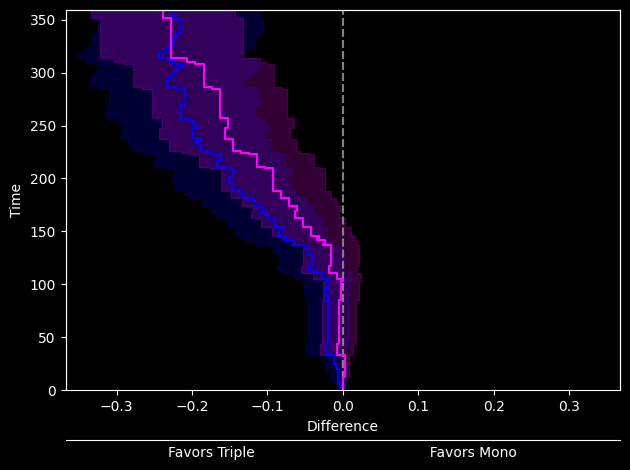

In [42]:
ax = bgcomp.plot_multi_span(color='blue', favors=False)
ax = bgcomp.plot_single_span(ax=ax, color='magenta', favors_spacing='\t\t\t\t\t',
                             favors_label=("Triple", "Mono"))
plt.tight_layout()

We see a difference in the two variations. These differences are related to the differences in the shared arms (with the multi-span approach integrating these differences into the final estimate, whereas the single-span does not). Another aspect to note is that the multi-span has more jumps. This feature again arises from the shared arms, where the shared arms cause shifts in the overall risk function. While less apparent on this plot, the single-span estimator will generally be more statistically efficient (provided the assumptions for both methods are met).

In [54]:
bgcomp.multi_span.tail(n=1)

,RD-MS,RD-MS_LCL,RD-MS_UCL,RD-MS_P
Time,,,,
358,-0.216137,-0.327936,-0.104338,0.000151




## Inverse Probability Weighting

Next, we consider the inverse probability weighting estimator. To save time, we incorporate the previous restriction by baseline CD4 into this analysis. The bridge IPW estimator is instead based on three nuisance models for three different weights: inverse odds of sampling, inverse probability of treatment, and inverse probability of censoring weights. These weights account for selection bias, confounding (in the case of observational data), and informative right censoring, respectively. The estimator can be accessed via `BridgeIPW` and is initialized in the same way as the g-computation functionality

In [43]:
bipw = BridgeIPW(data=ds, time='t', delta='delta', action='art', sample='study', censor='censor',
                 verbose=False)

A difference arises for the nuisance models. For the IPW estimator, each of the three nuisance models is specified separately.

In [44]:
# Sampling model for IOSW
bipw.sample_model(model="male + black + idu + age + age_rs0 + age_rs1 + age_rs2 + C(karnof_cat)")
# Action model for IPTW
bipw.action_model(model="1")
# Censoring model for IPCW
bipw.censor_model(model="male + black + idu + age + age_rs0 + age_rs1 + age_rs2 + C(karnof_cat)")

Now that the nuisance models are fit, we can estimate the risks (and then the diagnostic)

In [45]:
bipw.estimate_risks()

In [46]:
bipw.estimate_diagnostic()

(-0.2, 0.2)

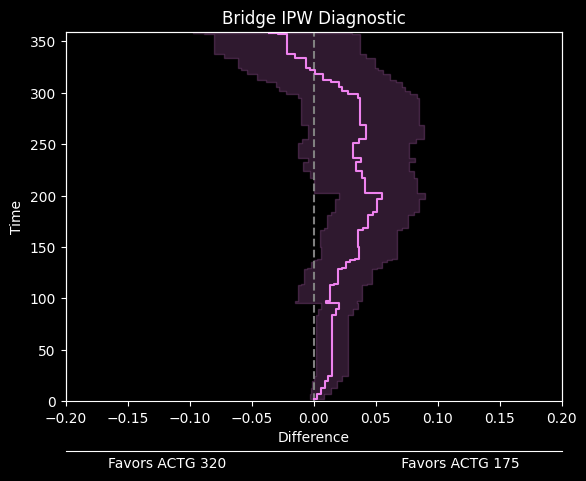

In [48]:
ax = bipw.plot_diagnostic(color='violet', favors_spacing="\t\t\t\t\t",
                          favors_label=("ACTG 320", "ACTG 175"))
ax.set_title("Bridge IPW Diagnostic")
ax.set_xlim([-0.2, 0.2])

In [50]:
bipw.diagnostic_test

,IRD,IRD_LCL,IRD_UCL,P-value
0,8.115081,-2.063345,18.293507,0.118136


Again, we see differences between the shared arms. While the P-value is larger (`0.12`) relative to g-computation, we should still be concerned regarding the comparability of the trials.

As before, we will apply the single-span and multi-span estimators for illustrative purposes.

In [51]:
bipw.estimate_single_span()

In [52]:
bipw.estimate_multi_span()

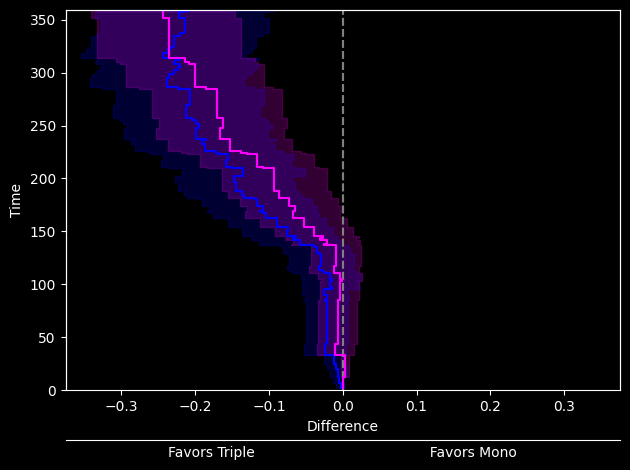

In [53]:
ax = bipw.plot_multi_span(color='blue', favors=False)
ax = bipw.plot_single_span(ax=ax, color='magenta', favors_spacing='\t\t\t\t\t',
                           favors_label=("Triple", "Mono"))
plt.tight_layout()

In [55]:
bipw.multi_span.tail(n=1)

,RD-MS,RD-MS_LCL,RD-MS_UCL,RD-MS_P
Time,,,,
358,-0.20796,-0.323704,-0.092216,0.000429


In general, the results between the g-computation and IPW estimators are similar. We also generally expect g-computation to be more statistically efficient (eg, narrower confidence intervals) than IPW when all corresponding assumptions hold for both estimators.

This concludes the illustrative examples.

## References

Hammer SM et al. (1996). A trial comparing nucleoside monotherapy with combination therapy in HIV-infected adults with CD4 cell counts from 200 to 500 per cubic millimeter. *New England Journal of Medicine*, 335(15):1081-1090.

Hammer SM, et al. (1997). A controlled trial of two nucleoside analogues plus indinavir in persons with human immunodeficiency virus infection and CD4 cell counts of 200 per cubic millimeter or less. *New England Journal of Medicine*, 337(11):725-733.

Zivich PN, Cole SR, Edwards JK, Shook-Sa BE, Breskin A, & Hudgens MG. (2025). Bridged treatment comparisons: an
illustrative application in HIV treatment. *American Journal of Epidemiology*, 194(6), 1687-1694.